In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define paths for your uploaded files
file_1 = 'Unemployment in India.csv'
file_2 = 'Unemployment_Rate_upto_11_2020.csv'

# Validation loader
if os.path.exists(file_1) and os.path.exists(file_2):
    df1 = pd.read_csv(file_1)
    df2 = pd.read_csv(file_2)
    print("Both Unemployment datasets loaded successfully!")
else:
    print("Check file placement. Ensure both CSV files are unzipped inside this specific folder.")

# Strip empty white spaces from columns to prevent indexing crashes
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print("\nDataset 1 Columns:", df1.columns.tolist())
print("Dataset 2 Columns:", df2.columns.tolist())

Both Unemployment datasets loaded successfully!

Dataset 1 Columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']
Dataset 2 Columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


In [8]:
print("--- Missing Values Audit ---")
print(df1.isnull().sum())

# Drop rows where all elements are missing to maintain data hygiene
df1 = df1.dropna()

# Convert Date columns cleanly without using the .str accessor
df1['Date'] = pd.to_datetime(df1['Date'], errors='coerce')
df2['Date'] = pd.to_datetime(df2['Date'], errors='coerce')

# Drop any rows where dates failed to parse cleanly
df1 = df1.dropna(subset=['Date'])
df2 = df2.dropna(subset=['Date'])

# Create explicit helper columns for monthly evaluation metrics
df1['Month_Name'] = df1['Date'].dt.strftime('%B')
df2['Month_Name'] = df2['Date'].dt.strftime('%B')

print("\nData parsing complete! Date structures successfully optimized.")
print("Dataset 1 sample rows:", len(df1))
print("Dataset 2 sample rows:", len(df2))

--- Missing Values Audit ---
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
Month_Name                                 0
dtype: int64

Data parsing complete! Date structures successfully optimized.
Dataset 1 sample rows: 740
Dataset 2 sample rows: 267


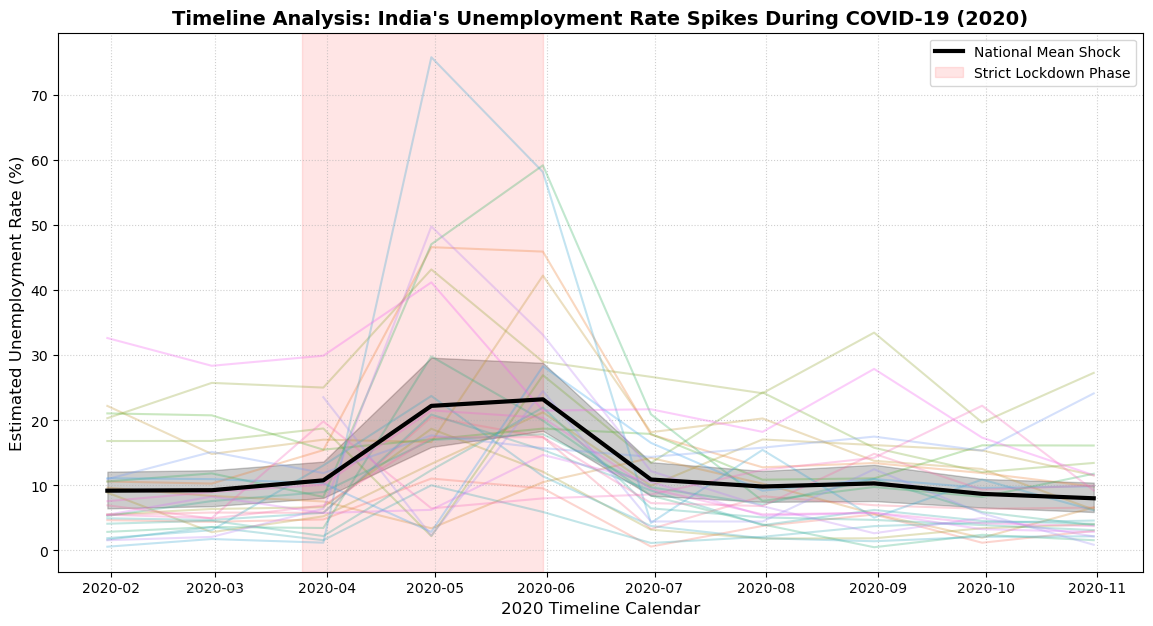

In [10]:
plt.figure(figsize=(14, 7))

# Plot state-level timelines using the cleaner 11_2020 dataset tracker
sns.lineplot(data=df2, x='Date', y='Estimated Unemployment Rate (%)', hue='Region', alpha=0.3, legend=False)
sns.lineplot(data=df2, x='Date', y='Estimated Unemployment Rate (%)', color='black', linewidth=3, label='National Mean Shock')

plt.title('Timeline Analysis: India\'s Unemployment Rate Spikes During COVID-19 (2020)', fontsize=14, fontweight='bold')
plt.xlabel('2020 Timeline Calendar', fontsize=12)
plt.ylabel('Estimated Unemployment Rate (%)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Highlight national lockdown window explicitly
plt.axvspan('2020-03-25', '2020-05-31', color='red', alpha=0.1, label='Strict Lockdown Phase')
plt.legend(loc='upper right')

# Save asset for submission documentation
plt.savefig('unemployment_timeline_spike.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\yashm\AppData\Local\Temp\ipykernel_22608\4024762285.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_impact, x='Estimated Unemployment Rate (%)', y='Region', palette='coolwarm')


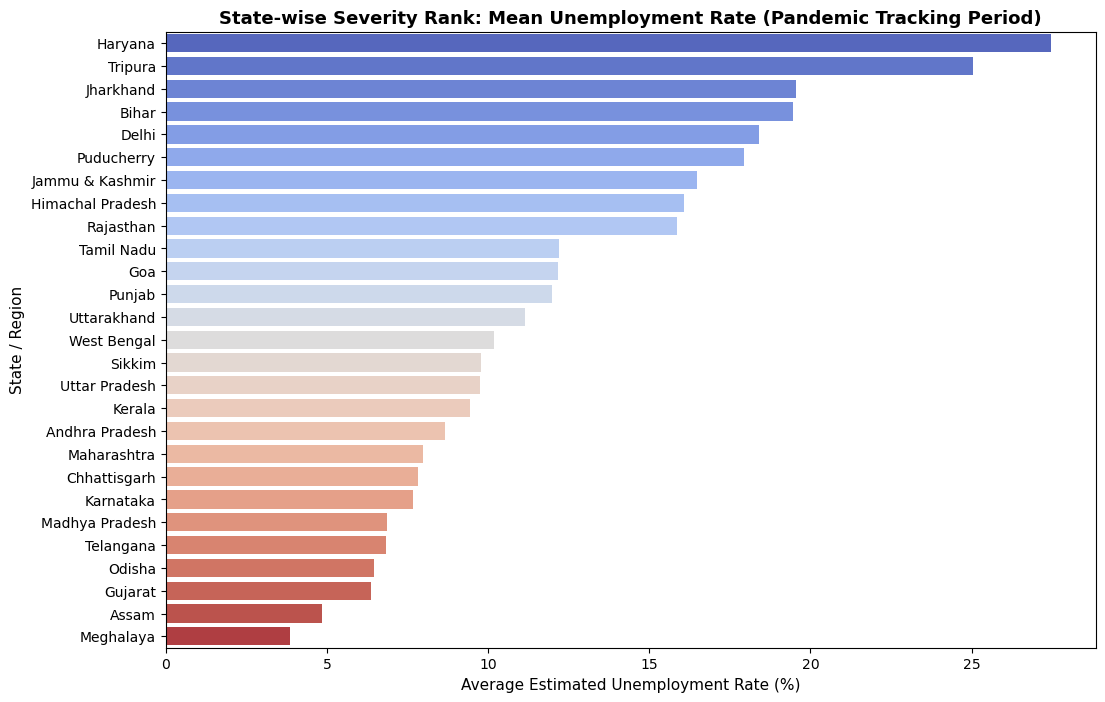

Visual output plots saved to folder path successfully.


In [13]:
# Calculate mean values grouped by Region/State
state_impact = df2.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index().sort_values(by='Estimated Unemployment Rate (%)', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=state_impact, x='Estimated Unemployment Rate (%)', y='Region', palette='coolwarm')
plt.title('State-wise Severity Rank: Mean Unemployment Rate (Pandemic Tracking Period)', fontsize=13, fontweight='bold')
plt.xlabel('Average Estimated Unemployment Rate (%)', fontsize=11)
plt.ylabel('State / Region', fontsize=11)

plt.savefig('regional_severity_ranking.png', dpi=300, bbox_inches='tight')
plt.show()
print("Visual output plots saved to folder path successfully.")